<a href="https://colab.research.google.com/github/mayurda8/project-cost-delay-intelligence/blob/main/ProjectCost_Delay_Intelligence.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

import os
import pandas as pd

# Find the dataset folder
base = "/content/mendeley_extracted"
folder = None

for root, dirs, files in os.walk(base):
    if "project_risk_raw_dataset.csv" in files:
        folder = root
        break

if folder is None:
    raise FileNotFoundError("Dataset folder not found.")

# File paths
risk_path = os.path.join(folder, "project_risk_raw_dataset.csv")
summary_path = os.path.join(
    folder, "project_delay_cost_overrun_summary_final.csv.xlsx"
)
ev_path = os.path.join(
    folder, "simulated_project_ev_metrics_final.csv.xlsx"
)

# Load risk CSV
risk_df = pd.read_csv(risk_path)

# Load Excel files directly
summary_df = pd.read_excel(summary_path, engine="openpyxl")
ev_df = pd.read_excel(ev_path, engine="openpyxl")

# If workbook data is in one column, split that column by commas
def split_single_column(df):
    if len(df.columns) == 1 and "," in str(df.columns[0]):
        header = str(df.columns[0]).split(",")
        rows = df.iloc[:, 0].astype(str).str.split(",", expand=True)
        rows.columns = header
        return rows
    return df

summary_df = split_single_column(summary_df)
ev_df = split_single_column(ev_df)

# Convert numeric fields where possible
for col in summary_df.columns:
    if col != "Project_ID":
        summary_df[col] = pd.to_numeric(summary_df[col], errors="coerce")

for col in ev_df.columns:
    if col not in ["Project_ID"]:
        ev_df[col] = pd.to_numeric(ev_df[col], errors="coerce")

# Store all datasets
datasets = {
    "risk": risk_df,
    "summary": summary_df,
    "ev": ev_df
}

# Display validation
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper(), "shape:", df.shape)
    print("Columns:", df.columns.tolist())
    display(df.head(3))

print("\nVALIDATION")
print("Risk:", risk_df.shape)
print("Summary:", summary_df.shape)
print("Earned Value:", ev_df.shape)
print("Summary Project_ID:", "Project_ID" in summary_df.columns)
print("EV Project_ID:", "Project_ID" in ev_df.columns)

print("\n✅ Finished.")


RISK shape: (4000, 51)
Columns: ['Project_ID', 'Project_Type', 'Team_Size', 'Project_Budget_USD', 'Estimated_Timeline_Months', 'Complexity_Score', 'Stakeholder_Count', 'Methodology_Used', 'Team_Experience_Level', 'Past_Similar_Projects', 'External_Dependencies_Count', 'Change_Request_Frequency', 'Project_Phase', 'Requirement_Stability', 'Team_Turnover_Rate', 'Vendor_Reliability_Score', 'Historical_Risk_Incidents', 'Communication_Frequency', 'Regulatory_Compliance_Level', 'Technology_Familiarity', 'Geographical_Distribution', 'Stakeholder_Engagement_Level', 'Schedule_Pressure', 'Budget_Utilization_Rate', 'Executive_Sponsorship', 'Funding_Source', 'Market_Volatility', 'Integration_Complexity', 'Resource_Availability', 'Priority_Level', 'Organizational_Change_Frequency', 'Cross_Functional_Dependencies', 'Previous_Delivery_Success_Rate', 'Technical_Debt_Level', 'Project_Manager_Experience', 'Org_Process_Maturity', 'Data_Security_Requirements', 'Key_Stakeholder_Availability', 'Tech_Environ

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Industry_Volatility,Client_Experience_Level,Change_Control_Maturity,Risk_Management_Maturity,Team_Colocation,Documentation_Quality,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,Extreme,First-time,Basic,Basic,Fully Colocated,Good,10,5,1.0,High
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,Stable,Occasional,Advanced,Formal,Fully Remote,Poor,9,3,1.0,Low
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,Stable,Regular,NaN,NaN,Hybrid,Good,5,1,1.0,Medium



SUMMARY shape: (4000, 7)
Columns: ['Project_ID', 'Estimated_Timeline_Months', 'Actual_Duration_Months', 'Planned_Budget', 'Actual_Cost', 'Schedule_Delay', 'Cost_Overrun']


,Project_ID,Estimated_Timeline_Months,Actual_Duration_Months,Planned_Budget,Actual_Cost,Schedule_Delay,Cost_Overrun
0,PROJ_0001,32,34,1526276.55,1.753360e+06,2,227083.429289
1,PROJ_0002,9,10,390790.15,4.423733e+05,1,51583.122837
2,PROJ_0003,6,7,246674.76,2.352246e+05,1,-11450.205052



EV shape: (72549, 15)
Columns: ['Project_ID', 'Month', 'PV', 'EV', 'AC', 'CPI_Monthly', 'SPI_Monthly', 'CV_Monthly', 'SV_Monthly', 'Estimated_Timeline_Months', 'Actual_Duration_Months', 'Planned_Budget', 'Actual_Cost', 'CPI_Cumulative', 'SPI_Cumulative']


,Project_ID,Month,PV,EV,AC,CPI_Monthly,SPI_Monthly,CV_Monthly,SV_Monthly,Estimated_Timeline_Months,Actual_Duration_Months,Planned_Budget,Actual_Cost,CPI_Cumulative,SPI_Cumulative
0,PROJ_0001,1,144301.102026,133645.521441,150258.773087,0.889436,0.926157,-16613.251646,-10655.580585,32,34,1526276.55,1.753360e+06,0.889436,0.926157
1,PROJ_0001,2,166015.080285,155829.899784,175069.801158,0.894134,1.021663,-2626.649728,470.400083,32,34,1526276.55,1.753360e+06,0.890102,0.938649
2,PROJ_0001,3,190574.551544,182448.989788,202865.294298,0.957676,1.083863,-1176.403135,2059.618746,32,34,1526276.55,1.753360e+06,0.899360,0.957363



VALIDATION
Risk: (4000, 51)
Summary: (4000, 7)
Earned Value: (72549, 15)
Summary Project_ID: True
EV Project_ID: True

✅ Finished.


In [2]:

import pandas as pd
import glob
import os

base_dir = "/content/mendeley_extracted"

summary_path = glob.glob(
    os.path.join(base_dir, "**", "project_delay_cost_overrun_summary_final.csv.xlsx"),
    recursive=True
)[0]

ev_path = glob.glob(
    os.path.join(base_dir, "**", "simulated_project_ev_metrics_final.csv.xlsx"),
    recursive=True
)[0]

# Read the Excel files
summary_df = pd.read_excel(summary_path, engine="openpyxl")
ev_df = pd.read_excel(ev_path, engine="openpyxl")

# If the workbook contains CSV text in one column,
# split that column into the actual fields.
def fix_single_column(df):
    if len(df.columns) == 1 and "," in str(df.columns[0]):
        headers = str(df.columns[0]).split(",")

        data = df.iloc[:, 0].astype(str).str.split(",", expand=True)
        data.columns = headers

        return data

    return df

summary_df = fix_single_column(summary_df)
ev_df = fix_single_column(ev_df)

# Clean column names
summary_df.columns = summary_df.columns.astype(str).str.strip()
ev_df.columns = ev_df.columns.astype(str).str.strip()

# Convert numeric-looking columns
for col in summary_df.columns:
    if col != "Project_ID":
        summary_df[col] = pd.to_numeric(
            summary_df[col], errors="coerce"
        )

for col in ev_df.columns:
    if col != "Project_ID":
        ev_df[col] = pd.to_numeric(
            ev_df[col], errors="coerce"
        )

# Show results
print("SUMMARY")
print("Shape:", summary_df.shape)
print("Columns:", summary_df.columns.tolist())
display(summary_df.head(3))

print("\nEARNED VALUE")
print("Shape:", ev_df.shape)
print("Columns:", ev_df.columns.tolist())
display(ev_df.head(3))

SUMMARY
Shape: (4000, 7)
Columns: ['Project_ID', 'Estimated_Timeline_Months', 'Actual_Duration_Months', 'Planned_Budget', 'Actual_Cost', 'Schedule_Delay', 'Cost_Overrun']


,Project_ID,Estimated_Timeline_Months,Actual_Duration_Months,Planned_Budget,Actual_Cost,Schedule_Delay,Cost_Overrun
0,PROJ_0001,32,34,1526276.55,1.753360e+06,2,227083.429289
1,PROJ_0002,9,10,390790.15,4.423733e+05,1,51583.122837
2,PROJ_0003,6,7,246674.76,2.352246e+05,1,-11450.205052



EARNED VALUE
Shape: (72549, 15)
Columns: ['Project_ID', 'Month', 'PV', 'EV', 'AC', 'CPI_Monthly', 'SPI_Monthly', 'CV_Monthly', 'SV_Monthly', 'Estimated_Timeline_Months', 'Actual_Duration_Months', 'Planned_Budget', 'Actual_Cost', 'CPI_Cumulative', 'SPI_Cumulative']


,Project_ID,Month,PV,EV,AC,CPI_Monthly,SPI_Monthly,CV_Monthly,SV_Monthly,Estimated_Timeline_Months,Actual_Duration_Months,Planned_Budget,Actual_Cost,CPI_Cumulative,SPI_Cumulative
0,PROJ_0001,1,144301.102026,133645.521441,150258.773087,0.889436,0.926157,-16613.251646,-10655.580585,32,34,1526276.55,1.753360e+06,0.889436,0.926157
1,PROJ_0001,2,166015.080285,155829.899784,175069.801158,0.894134,1.021663,-2626.649728,470.400083,32,34,1526276.55,1.753360e+06,0.890102,0.938649
2,PROJ_0001,3,190574.551544,182448.989788,202865.294298,0.957676,1.083863,-1176.403135,2059.618746,32,34,1526276.55,1.753360e+06,0.899360,0.957363


In [3]:

# Step 3: Data quality checks

# Clean Project_ID values
for df in [risk_df, summary_df, ev_df]:
    df["Project_ID"] = df["Project_ID"].astype(str).str.strip()

print("1. DUPLICATE PROJECT IDs")
print("Risk:", risk_df["Project_ID"].duplicated().sum())
print("Summary:", summary_df["Project_ID"].duplicated().sum())

print("\n2. MISSING VALUES — RISK DATASET")
print(risk_df.isnull().sum()[risk_df.isnull().sum() > 0])

print("\n3. MISSING VALUES — SUMMARY DATASET")
print(summary_df.isnull().sum()[summary_df.isnull().sum() > 0])

print("\n4. MISSING VALUES — EARNED VALUE DATASET")
print(ev_df.isnull().sum()[ev_df.isnull().sum() > 0])

print("\n5. PROJECT ID COVERAGE")
print("Risk unique projects:", risk_df["Project_ID"].nunique())
print("Summary unique projects:", summary_df["Project_ID"].nunique())
print("Earned Value unique projects:", ev_df["Project_ID"].nunique())

print("\n6. PROJECTS PRESENT IN BOTH RISK AND SUMMARY")
risk_ids = set(risk_df["Project_ID"])
summary_ids = set(summary_df["Project_ID"])

print("In both:", len(risk_ids & summary_ids))
print("Only in risk:", len(risk_ids - summary_ids))
print("Only in summary:", len(summary_ids - risk_ids))

1. DUPLICATE PROJECT IDs
Risk: 0
Summary: 0

2. MISSING VALUES — RISK DATASET
Tech_Environment_Stability    2619
Change_Control_Maturity        780
Risk_Management_Maturity       791
dtype: int64

3. MISSING VALUES — SUMMARY DATASET
Series([], dtype: int64)

4. MISSING VALUES — EARNED VALUE DATASET
Series([], dtype: int64)

5. PROJECT ID COVERAGE
Risk unique projects: 4000
Summary unique projects: 4000
Earned Value unique projects: 4000

6. PROJECTS PRESENT IN BOTH RISK AND SUMMARY
In both: 4000
Only in risk: 0
Only in summary: 0


In [4]:

# Step 4: Merge Risk and Summary datasets

# Make sure Project_ID is clean
for df in [risk_df, summary_df]:
    df["Project_ID"] = df["Project_ID"].astype(str).str.strip()

# Merge using Project_ID
project_df = pd.merge(
    risk_df,
    summary_df,
    on="Project_ID",
    how="inner",
    suffixes=("_Risk", "_Summary"),
    validate="one_to_one"
)

# Check the merged dataset
print("Merged dataset shape:", project_df.shape)
print("Unique projects:", project_df["Project_ID"].nunique())
print("Duplicate Project_IDs:", project_df["Project_ID"].duplicated().sum())

print("\nMerged columns:")
print(project_df.columns.tolist())

print("\nFirst 5 rows:")
display(project_df.head())

print("\nProject outcome summary:")
display(
    project_df[
        [
            "Project_ID",
            "Estimated_Timeline_Months_Summary",
            "Actual_Duration_Months",
            "Planned_Budget",
            "Actual_Cost",
            "Schedule_Delay",
            "Cost_Overrun"
        ]
    ].head()
)

Merged dataset shape: (4000, 57)
Unique projects: 4000
Duplicate Project_IDs: 0

Merged columns:
['Project_ID', 'Project_Type', 'Team_Size', 'Project_Budget_USD', 'Estimated_Timeline_Months_Risk', 'Complexity_Score', 'Stakeholder_Count', 'Methodology_Used', 'Team_Experience_Level', 'Past_Similar_Projects', 'External_Dependencies_Count', 'Change_Request_Frequency', 'Project_Phase', 'Requirement_Stability', 'Team_Turnover_Rate', 'Vendor_Reliability_Score', 'Historical_Risk_Incidents', 'Communication_Frequency', 'Regulatory_Compliance_Level', 'Technology_Familiarity', 'Geographical_Distribution', 'Stakeholder_Engagement_Level', 'Schedule_Pressure', 'Budget_Utilization_Rate', 'Executive_Sponsorship', 'Funding_Source', 'Market_Volatility', 'Integration_Complexity', 'Resource_Availability', 'Priority_Level', 'Organizational_Change_Frequency', 'Cross_Functional_Dependencies', 'Previous_Delivery_Success_Rate', 'Technical_Debt_Level', 'Project_Manager_Experience', 'Org_Process_Maturity', 'Data_

,Project_ID,Project_Type,Team_Size,Project_Budget_USD,Estimated_Timeline_Months_Risk,Complexity_Score,Stakeholder_Count,Methodology_Used,Team_Experience_Level,Past_Similar_Projects,...,Project_Start_Month,Current_Phase_Duration_Months,Seasonal_Risk_Factor,Risk_Level,Estimated_Timeline_Months_Summary,Actual_Duration_Months,Planned_Budget,Actual_Cost,Schedule_Delay,Cost_Overrun
0,PROJ_0001,Construction,32,1526276.55,32,9.70,16,Waterfall,Senior,3,...,10,5,1.0,High,32,34,1526276.55,1.753360e+06,2,227083.429289
1,PROJ_0002,Manufacturing,2,390790.15,9,2.72,9,Kanban,Mixed,0,...,9,3,1.0,Low,9,10,390790.15,4.423733e+05,1,51583.122837
2,PROJ_0003,Manufacturing,2,246674.76,6,2.04,7,Agile,Mixed,1,...,5,1,1.0,Medium,6,7,246674.76,2.352246e+05,1,-11450.205052
3,PROJ_0004,IT,12,1427830.63,17,7.54,16,Scrum,Mixed,0,...,12,6,1.1,High,17,22,1427830.63,1.579513e+06,5,151682.465664
4,PROJ_0005,Construction,24,1696746.64,24,6.68,17,Hybrid,Junior,0,...,9,6,1.0,High,24,26,1696746.64,1.840761e+06,2,144014.497689



Project outcome summary:


,Project_ID,Estimated_Timeline_Months_Summary,Actual_Duration_Months,Planned_Budget,Actual_Cost,Schedule_Delay,Cost_Overrun
0,PROJ_0001,32,34,1526276.55,1.753360e+06,2,227083.429289
1,PROJ_0002,9,10,390790.15,4.423733e+05,1,51583.122837
2,PROJ_0003,6,7,246674.76,2.352246e+05,1,-11450.205052
3,PROJ_0004,17,22,1427830.63,1.579513e+06,5,151682.465664
4,PROJ_0005,24,26,1696746.64,1.840761e+06,2,144014.497689


In [5]:

# Step 5: Project delay and cost overrun analysis

import pandas as pd

# Create a working copy
analysis_df = project_df.copy()

# Ensure outcome columns are numeric
numeric_cols = [
    "Schedule_Delay",
    "Cost_Overrun",
    "Planned_Budget",
    "Actual_Cost",
    "Estimated_Timeline_Months_Summary",
    "Actual_Duration_Months"
]

for col in numeric_cols:
    analysis_df[col] = pd.to_numeric(
        analysis_df[col], errors="coerce"
    )

# Create indicators
analysis_df["Delayed_Project"] = (
    analysis_df["Schedule_Delay"] > 0
)

analysis_df["Over_Budget_Project"] = (
    analysis_df["Cost_Overrun"] > 0
)

# Overall project summary
total_projects = len(analysis_df)

delayed_projects = analysis_df["Delayed_Project"].sum()
over_budget_projects = analysis_df["Over_Budget_Project"].sum()

print("OVERALL PROJECT PERFORMANCE")
print("---------------------------")
print("Total projects:", total_projects)

print(
    "Delayed projects:",
    delayed_projects,
    f"({delayed_projects / total_projects * 100:.2f}%)"
)

print(
    "Over-budget projects:",
    over_budget_projects,
    f"({over_budget_projects / total_projects * 100:.2f}%)"
)

print(
    "Average schedule delay (months):",
    round(analysis_df["Schedule_Delay"].mean(), 2)
)

print(
    "Average cost overrun (USD):",
    round(analysis_df["Cost_Overrun"].mean(), 2)
)

print(
    "Total cost overrun (USD):",
    round(analysis_df["Cost_Overrun"].sum(), 2)
)

# Performance by project type
print("\nPERFORMANCE BY PROJECT TYPE")
print("---------------------------")

type_summary = (
    analysis_df
    .groupby("Project_Type")
    .agg(
        Total_Projects=("Project_ID", "count"),
        Delayed_Projects=("Delayed_Project", "sum"),
        Over_Budget_Projects=("Over_Budget_Project", "sum"),
        Average_Delay_Months=("Schedule_Delay", "mean"),
        Average_Cost_Overrun_USD=("Cost_Overrun", "mean")
    )
    .reset_index()
)

type_summary["Delayed_Percent"] = (
    type_summary["Delayed_Projects"]
    / type_summary["Total_Projects"] * 100
)

type_summary["Over_Budget_Percent"] = (
    type_summary["Over_Budget_Projects"]
    / type_summary["Total_Projects"] * 100
)

type_summary = type_summary.round(2)

display(type_summary)

OVERALL PROJECT PERFORMANCE
---------------------------
Total projects: 4000
Delayed projects: 2448 (61.20%)
Over-budget projects: 3395 (84.88%)
Average schedule delay (months): 0.99
Average cost overrun (USD): 72518.3
Total cost overrun (USD): 290073191.25

PERFORMANCE BY PROJECT TYPE
---------------------------


,Project_Type,Total_Projects,Delayed_Projects,Over_Budget_Projects,Average_Delay_Months,Average_Cost_Overrun_USD,Delayed_Percent,Over_Budget_Percent
0,Construction,797,421,720,0.78,101994.44,52.82,90.34
1,Healthcare,398,211,324,0.65,41588.32,53.02,81.41
2,IT,1381,936,1118,1.10,55923.68,67.78,80.96
3,Manufacturing,418,213,341,0.64,38851.24,50.96,81.58
4,Marketing,418,231,352,0.76,50108.32,55.26,84.21
5,R&D,588,436,540,1.66,132339.76,74.15,91.84


In [6]:

# Step 6: Analyse project outcomes by Risk Level

risk_summary = (
    analysis_df
    .groupby("Risk_Level", dropna=False)
    .agg(
        Total_Projects=("Project_ID", "count"),
        Delayed_Projects=("Delayed_Project", "sum"),
        Over_Budget_Projects=("Over_Budget_Project", "sum"),
        Average_Delay_Months=("Schedule_Delay", "mean"),
        Average_Cost_Overrun_USD=("Cost_Overrun", "mean"),
        Total_Cost_Overrun_USD=("Cost_Overrun", "sum")
    )
    .reset_index()
)

risk_summary["Delayed_Percent"] = (
    risk_summary["Delayed_Projects"]
    / risk_summary["Total_Projects"] * 100
)

risk_summary["Over_Budget_Percent"] = (
    risk_summary["Over_Budget_Projects"]
    / risk_summary["Total_Projects"] * 100
)

risk_summary = risk_summary.round(2)

print("PROJECT OUTCOMES BY RISK LEVEL")
display(risk_summary)

print("\nPROJECT COUNTS BY RISK LEVEL")
display(
    analysis_df["Risk_Level"]
    .value_counts(dropna=False)
    .rename_axis("Risk_Level")
    .reset_index(name="Project_Count")
)

PROJECT OUTCOMES BY RISK LEVEL


,Risk_Level,Total_Projects,Delayed_Projects,Over_Budget_Projects,Average_Delay_Months,Average_Cost_Overrun_USD,Total_Cost_Overrun_USD,Delayed_Percent,Over_Budget_Percent
0,Critical,762,435,663,0.91,92783.61,70701112.08,57.09,87.01
1,High,1036,656,891,1.09,81370.32,84299653.06,63.32,86.00
2,Low,806,496,656,0.94,55880.22,45039455.22,61.54,81.39
3,Medium,1396,861,1185,0.99,64493.53,90032970.90,61.68,84.89



PROJECT COUNTS BY RISK LEVEL


,Risk_Level,Project_Count
0,Medium,1396
1,High,1036
2,Low,806
3,Critical,762


In [7]:

# Step 7: Combined schedule and cost outcome by risk level

# Create an indicator for projects that were both delayed and over budget
analysis_df["Delayed_And_Over_Budget"] = (
    (analysis_df["Schedule_Delay"] > 0) &
    (analysis_df["Cost_Overrun"] > 0)
)

# Summarise outcomes by risk level
risk_outcome_summary = (
    analysis_df
    .groupby("Risk_Level")
    .agg(
        Total_Projects=("Project_ID", "count"),
        Delayed=("Delayed_Project", "sum"),
        Over_Budget=("Over_Budget_Project", "sum"),
        Both_Delayed_And_Over_Budget=("Delayed_And_Over_Budget", "sum"),
        Avg_Delay_Months=("Schedule_Delay", "mean"),
        Avg_Cost_Overrun_USD=("Cost_Overrun", "mean")
    )
    .reset_index()
)

# Calculate percentages
risk_outcome_summary["Delayed_Percent"] = (
    risk_outcome_summary["Delayed"]
    / risk_outcome_summary["Total_Projects"] * 100
)

risk_outcome_summary["Over_Budget_Percent"] = (
    risk_outcome_summary["Over_Budget"]
    / risk_outcome_summary["Total_Projects"] * 100
)

risk_outcome_summary["Both_Percent"] = (
    risk_outcome_summary["Both_Delayed_And_Over_Budget"]
    / risk_outcome_summary["Total_Projects"] * 100
)

# Arrange risk levels
risk_order = ["Low", "Medium", "High", "Critical"]

risk_outcome_summary["Risk_Level"] = pd.Categorical(
    risk_outcome_summary["Risk_Level"],
    categories=risk_order,
    ordered=True
)

risk_outcome_summary = (
    risk_outcome_summary
    .sort_values("Risk_Level")
    .round(2)
)

print("RISK LEVEL OUTCOME SUMMARY")
display(risk_outcome_summary)

print("\nOVERALL PROJECTS BOTH DELAYED AND OVER BUDGET")
both_count = analysis_df["Delayed_And_Over_Budget"].sum()
print("Count:", both_count)
print("Percentage:", round(both_count / len(analysis_df) * 100, 2), "%")

RISK LEVEL OUTCOME SUMMARY


,Risk_Level,Total_Projects,Delayed,Over_Budget,Both_Delayed_And_Over_Budget,Avg_Delay_Months,Avg_Cost_Overrun_USD,Delayed_Percent,Over_Budget_Percent,Both_Percent
2,Low,806,496,656,417,0.94,55880.22,61.54,81.39,51.74
3,Medium,1396,861,1185,740,0.99,64493.53,61.68,84.89,53.01
1,High,1036,656,891,570,1.09,81370.32,63.32,86.00,55.02
0,Critical,762,435,663,383,0.91,92783.61,57.09,87.01,50.26



OVERALL PROJECTS BOTH DELAYED AND OVER BUDGET
Count: 2110
Percentage: 52.75 %


In [8]:

# Step 8: Prepare dashboard KPI metrics

total_projects = len(analysis_df)

delayed_projects = int(
    (analysis_df["Schedule_Delay"] > 0).sum()
)

over_budget_projects = int(
    (analysis_df["Cost_Overrun"] > 0).sum()
)

both_projects = int(
    (
        (analysis_df["Schedule_Delay"] > 0) &
        (analysis_df["Cost_Overrun"] > 0)
    ).sum()
)

total_planned_budget = analysis_df["Planned_Budget"].sum()
total_actual_cost = analysis_df["Actual_Cost"].sum()

total_cost_overrun = (
    analysis_df["Actual_Cost"].sum()
    - analysis_df["Planned_Budget"].sum()
)

avg_delay = analysis_df["Schedule_Delay"].mean()

delayed_percent = delayed_projects / total_projects * 100
over_budget_percent = over_budget_projects / total_projects * 100
both_percent = both_projects / total_projects * 100

print("PROJECT COST & DELAY INTELLIGENCE — KPI SUMMARY")
print("=" * 55)

print(f"Total Projects: {total_projects:,}")
print(f"Delayed Projects: {delayed_projects:,}")
print(f"Delayed Projects (%): {delayed_percent:.2f}%")
print(f"Over-Budget Projects: {over_budget_projects:,}")
print(f"Over-Budget Projects (%): {over_budget_percent:.2f}%")
print(f"Both Delayed and Over Budget: {both_projects:,}")
print(f"Both (%): {both_percent:.2f}%")
print(f"Average Schedule Delay: {avg_delay:.2f} months")

print(f"\nTotal Planned Budget: ${total_planned_budget:,.2f}")
print(f"Total Actual Cost: ${total_actual_cost:,.2f}")
print(f"Net Cost Difference: ${total_cost_overrun:,.2f}")

PROJECT COST & DELAY INTELLIGENCE — KPI SUMMARY
Total Projects: 4,000
Delayed Projects: 2,448
Delayed Projects (%): 61.20%
Over-Budget Projects: 3,395
Over-Budget Projects (%): 84.88%
Both Delayed and Over Budget: 2,110
Both (%): 52.75%
Average Schedule Delay: 0.99 months

Total Planned Budget: $4,572,126,011.43
Total Actual Cost: $4,862,199,202.68
Net Cost Difference: $290,073,191.25


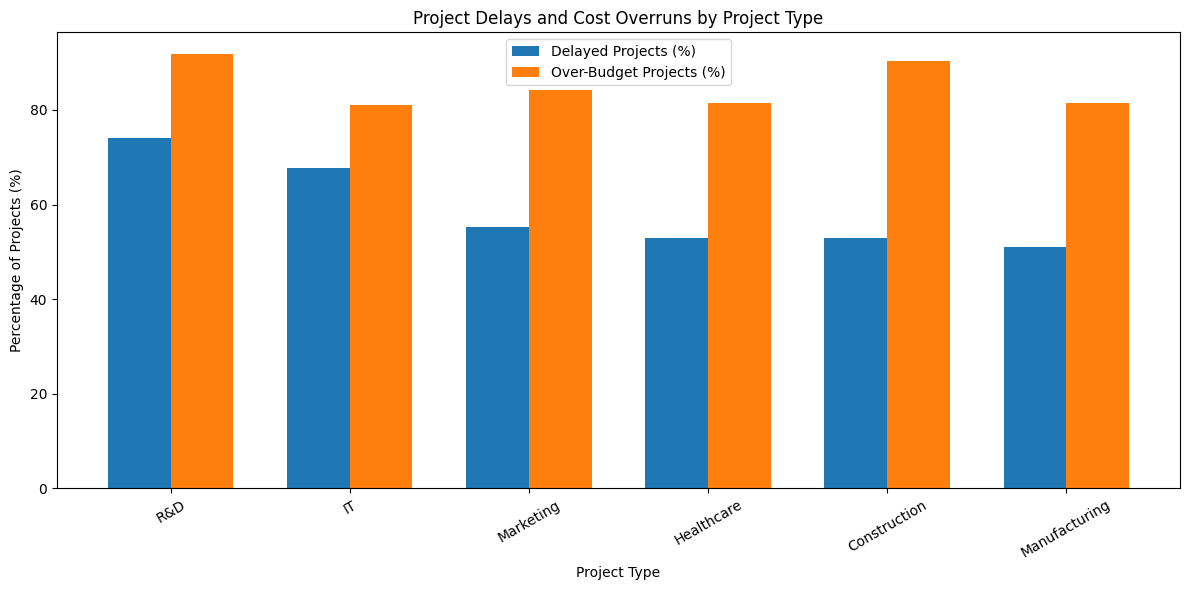

,Project_Type,Total_Projects,Delayed_Percent,Over_Budget_Percent
5,R&D,588,74.15,91.84
2,IT,1381,67.78,80.96
4,Marketing,418,55.26,84.21
1,Healthcare,398,53.02,81.41
0,Construction,797,52.82,90.34
3,Manufacturing,418,50.96,81.58


In [9]:

# Step 9: Chart — delay and cost overrun by project type

import matplotlib.pyplot as plt
import pandas as pd

# Summarise data by project type
chart_df = (
    analysis_df
    .groupby("Project_Type")
    .agg(
        Total_Projects=("Project_ID", "count"),
        Delayed_Projects=("Delayed_Project", "sum"),
        Over_Budget_Projects=("Over_Budget_Project", "sum")
    )
    .reset_index()
)

# Calculate percentages
chart_df["Delayed_Percent"] = (
    chart_df["Delayed_Projects"]
    / chart_df["Total_Projects"] * 100
)

chart_df["Over_Budget_Percent"] = (
    chart_df["Over_Budget_Projects"]
    / chart_df["Total_Projects"] * 100
)

# Sort by delay percentage
chart_df = chart_df.sort_values(
    "Delayed_Percent",
    ascending=False
)

# Plot grouped bars
x = range(len(chart_df))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(
    [i - width/2 for i in x],
    chart_df["Delayed_Percent"],
    width,
    label="Delayed Projects (%)"
)

plt.bar(
    [i + width/2 for i in x],
    chart_df["Over_Budget_Percent"],
    width,
    label="Over-Budget Projects (%)"
)

plt.xticks(list(x), chart_df["Project_Type"], rotation=30)
plt.ylabel("Percentage of Projects (%)")
plt.xlabel("Project Type")
plt.title("Project Delays and Cost Overruns by Project Type")
plt.legend()
plt.tight_layout()
plt.show()

# Display the exact values used in the chart
display(
    chart_df[
        [
            "Project_Type",
            "Total_Projects",
            "Delayed_Percent",
            "Over_Budget_Percent"
        ]
    ].round(2)
)

Example Project ID: PROJ_1205
Number of monthly records: 43


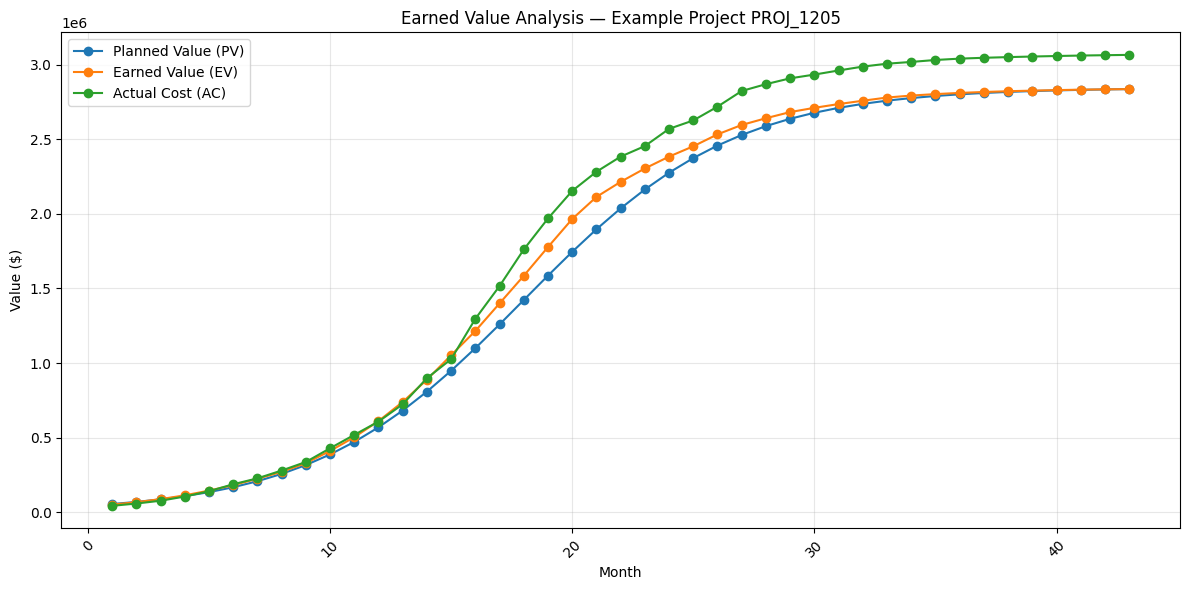

In [10]:

import matplotlib.pyplot as plt

# Select one project with the most monthly records
project_counts = ev_df.groupby("Project_ID").size()
sample_project_id = project_counts.idxmax()

# Get the monthly records for this project
sample_ev = ev_df[ev_df["Project_ID"] == sample_project_id].copy()
sample_ev = sample_ev.sort_values("Month")

print("Example Project ID:", sample_project_id)
print("Number of monthly records:", len(sample_ev))

# Plot earned value metrics
plt.figure(figsize=(12, 6))

plt.plot(sample_ev["Month"], sample_ev["PV"], marker="o", label="Planned Value (PV)")
plt.plot(sample_ev["Month"], sample_ev["EV"], marker="o", label="Earned Value (EV)")
plt.plot(sample_ev["Month"], sample_ev["AC"], marker="o", label="Actual Cost (AC)")

plt.title(f"Earned Value Analysis — Example Project {sample_project_id}")
plt.xlabel("Month")
plt.ylabel("Value ($)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:

# Sort the example project's records by month
sample_ev = sample_ev.sort_values("Month")

# Get the final monthly record
final_row = sample_ev.iloc[-1]

print("Example Project:", sample_project_id)
print("Final Month:", final_row["Month"])
print("Final Cumulative CPI:", round(final_row["CPI_Cumulative"], 3))
print("Final Cumulative SPI:", round(final_row["SPI_Cumulative"], 3))

print("\nFinal Earned Value Metrics:")
print("Planned Value (PV):", round(final_row["PV"], 2))
print("Earned Value (EV):", round(final_row["EV"], 2))
print("Actual Cost (AC):", round(final_row["AC"], 2))

Example Project: PROJ_1205
Final Month: 43
Final Cumulative CPI: 0.925
Final Cumulative SPI: 1.0

Final Earned Value Metrics:
Planned Value (PV): 2836146.17
Earned Value (EV): 2836146.17
Actual Cost (AC): 3065462.84


In [12]:

# Estimate at Completion (EAC)
BAC = final_row["Planned_Budget"]
CPI = final_row["CPI_Cumulative"]

EAC = BAC / CPI
VAC = BAC - EAC

print("Example Project:", sample_project_id)
print("Budget at Completion (BAC):", round(BAC, 2))
print("Cumulative CPI:", round(CPI, 3))
print("Estimated Cost at Completion (EAC):", round(EAC, 2))
print("Variance at Completion (VAC):", round(VAC, 2))

Example Project: PROJ_1205
Budget at Completion (BAC): 2836146.17
Cumulative CPI: 0.925
Estimated Cost at Completion (EAC): 3065462.84
Variance at Completion (VAC): -229316.67


In [13]:

overrun_amount = EAC - BAC
overrun_percent = (overrun_amount / BAC) * 100

print("Example Project:", sample_project_id)
print("Forecast Overrun ($):", round(overrun_amount, 2))
print("Forecast Overrun (%):", round(overrun_percent, 2))

Example Project: PROJ_1205
Forecast Overrun ($): 229316.67
Forecast Overrun (%): 8.09


In [14]:

# Get each project's final monthly record
final_ev = (
    ev_df.sort_values("Month")
    .groupby("Project_ID")
    .tail(1)
    .copy()
)

# Keep records with valid positive cumulative CPI and budget
final_ev = final_ev[
    (final_ev["CPI_Cumulative"] > 0) &
    (final_ev["Planned_Budget"] > 0)
].copy()

# Calculate forecast metrics
final_ev["EAC"] = (
    final_ev["Planned_Budget"] / final_ev["CPI_Cumulative"]
)

final_ev["VAC"] = (
    final_ev["Planned_Budget"] - final_ev["EAC"]
)

final_ev["Forecast_Overrun_Percent"] = (
    (final_ev["EAC"] - final_ev["Planned_Budget"])
    / final_ev["Planned_Budget"] * 100
)

# Summarise the results
print("Projects analysed:", final_ev["Project_ID"].nunique())
print("Projects forecast over budget:", (final_ev["VAC"] < 0).sum())
print(
    "Percentage forecast over budget:",
    round((final_ev["VAC"] < 0).mean() * 100, 2)
)

print(
    "Average forecast overrun percentage:",
    round(final_ev.loc[final_ev["VAC"] < 0, "Forecast_Overrun_Percent"].mean(), 2)
)

print("\nLargest forecast overruns:")
print(
    final_ev.nlargest(10, "Forecast_Overrun_Percent")[
        ["Project_ID", "Planned_Budget", "CPI_Cumulative", "EAC",
         "VAC", "Forecast_Overrun_Percent"]
    ].to_string(index=False)
)

Projects analysed: 4000
Projects forecast over budget: 3395
Percentage forecast over budget: 84.88
Average forecast overrun percentage: 7.59

Largest forecast overruns:
Project_ID  Planned_Budget  CPI_Cumulative          EAC            VAC  Forecast_Overrun_Percent
 PROJ_1049       440611.26        0.744565 5.917702e+05 -151158.968090                 34.306651
 PROJ_2136       680247.98        0.749155 9.080202e+05 -227772.214603                 33.483703
 PROJ_3672       627390.84        0.751628 8.347091e+05 -207318.284306                 33.044519
 PROJ_0210       932503.20        0.753603 1.237394e+06 -304890.499602                 32.695920
 PROJ_3432       561653.54        0.755023 7.438892e+05 -182235.627369                 32.446271
 PROJ_3442      1148198.22        0.764684 1.501533e+06 -353334.503718                 30.772953
 PROJ_2828      1017120.21        0.767083 1.325958e+06 -308837.504688                 30.363914
 PROJ_3201       634986.18        0.769555 8.251343e+05

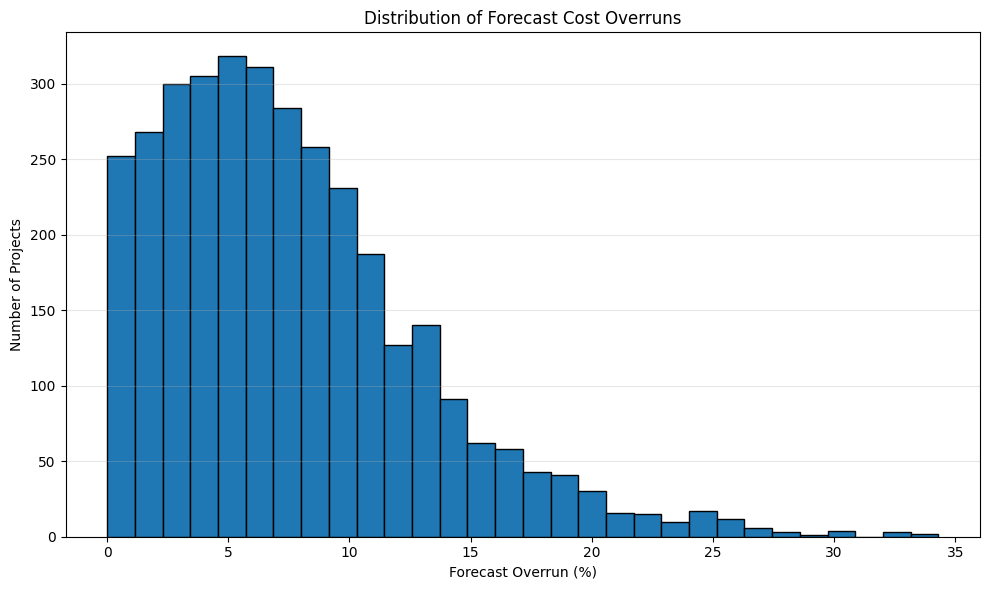

Projects included: 3395
Median forecast overrun (%): 6.73
Maximum forecast overrun (%): 34.31


In [15]:

import matplotlib.pyplot as plt

# Select projects forecast to exceed budget
over_budget = final_ev[
    final_ev["Forecast_Overrun_Percent"] > 0
].copy()

plt.figure(figsize=(10, 6))

plt.hist(
    over_budget["Forecast_Overrun_Percent"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Forecast Cost Overruns")
plt.xlabel("Forecast Overrun (%)")
plt.ylabel("Number of Projects")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print("Projects included:", len(over_budget))
print(
    "Median forecast overrun (%):",
    round(over_budget["Forecast_Overrun_Percent"].median(), 2)
)
print(
    "Maximum forecast overrun (%):",
    round(over_budget["Forecast_Overrun_Percent"].max(), 2)
)

In [16]:

# Add project type to each project's final forecast record
type_df = final_ev.merge(
    analysis_df[["Project_ID", "Project_Type"]],
    on="Project_ID",
    how="left"
)

# Summarise forecast overruns by project type
type_overrun = (
    type_df[type_df["Forecast_Overrun_Percent"] > 0]
    .groupby("Project_Type")
    .agg(
        Projects_Over_Budget=("Project_ID", "nunique"),
        Average_Overrun_Percent=("Forecast_Overrun_Percent", "mean"),
        Median_Overrun_Percent=("Forecast_Overrun_Percent", "median"),
        Maximum_Overrun_Percent=("Forecast_Overrun_Percent", "max")
    )
    .sort_values("Average_Overrun_Percent", ascending=False)
    .round(2)
)

print(type_overrun)

               Projects_Over_Budget  Average_Overrun_Percent  \
Project_Type                                                   
R&D                             540                     8.42   
IT                             1118                     8.08   
Marketing                       352                     7.60   
Healthcare                      324                     7.45   
Manufacturing                   341                     7.02   
Construction                    720                     6.55   

               Median_Overrun_Percent  Maximum_Overrun_Percent  
Project_Type                                                    
R&D                              7.45                    26.99  
IT                               6.94                    33.48  
Marketing                        6.84                    28.92  
Healthcare                       6.27                    32.45  
Manufacturing                    6.09                    34.31  
Construction                    

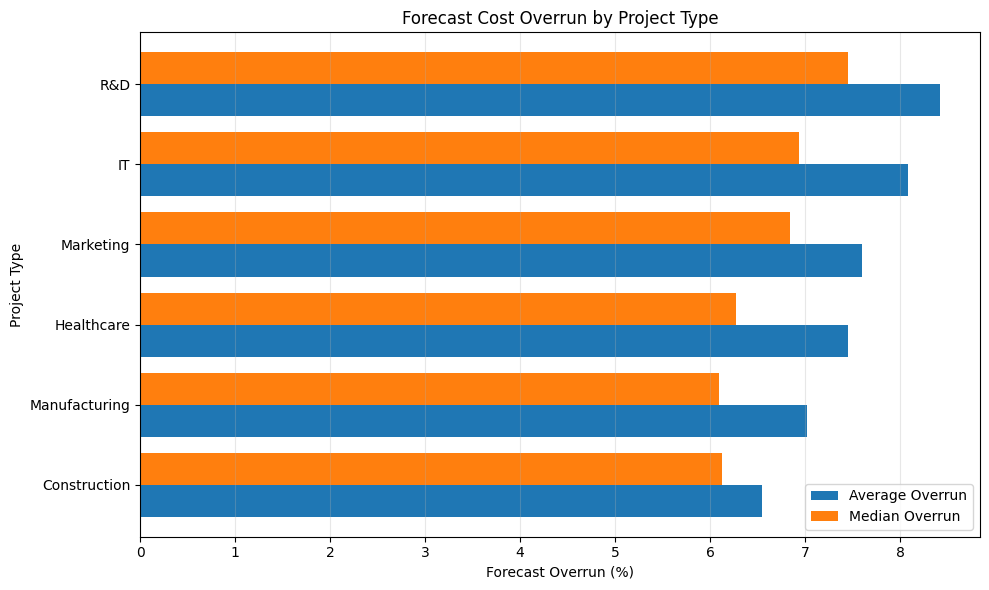

In [17]:

import matplotlib.pyplot as plt

plot_df = type_overrun[
    ["Average_Overrun_Percent", "Median_Overrun_Percent"]
].sort_values("Average_Overrun_Percent", ascending=True)

ax = plot_df.plot(
    kind="barh",
    figsize=(10, 6),
    width=0.8
)

ax.set_title("Forecast Cost Overrun by Project Type")
ax.set_xlabel("Forecast Overrun (%)")
ax.set_ylabel("Project Type")
ax.legend(["Average Overrun", "Median Overrun"])
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:

# Select project details and outcomes
project_details = analysis_df[
    [
        "Project_ID",
        "Project_Type",
        "Risk_Level",
        "Schedule_Delay",
        "Cost_Overrun",
        "Delayed_Project",
        "Over_Budget_Project"
    ]
].copy()

# Select final earned-value forecast metrics
forecast_details = final_ev[
    [
        "Project_ID",
        "CPI_Cumulative",
        "SPI_Cumulative",
        "Planned_Budget",
        "Actual_Cost",
        "EAC",
        "VAC",
        "Forecast_Overrun_Percent"
    ]
].copy()

# Merge into one project-level table
portfolio_df = project_details.merge(
    forecast_details,
    on="Project_ID",
    how="left",
    validate="one_to_one"
)

print("Portfolio dataset shape:", portfolio_df.shape)
print("Unique projects:", portfolio_df["Project_ID"].nunique())
print("Duplicate Project IDs:", portfolio_df["Project_ID"].duplicated().sum())
print("Missing values:", portfolio_df.isna().sum().sum())

print("\nPreview:")
display(portfolio_df.head())

Portfolio dataset shape: (4000, 14)
Unique projects: 4000
Duplicate Project IDs: 0
Missing values: 0

Preview:


,Project_ID,Project_Type,Risk_Level,Schedule_Delay,Cost_Overrun,Delayed_Project,Over_Budget_Project,CPI_Cumulative,SPI_Cumulative,Planned_Budget,Actual_Cost,EAC,VAC,Forecast_Overrun_Percent
0,PROJ_0001,Construction,High,2,227083.429289,True,True,0.870487,1.0,1526276.55,1.753360e+06,1.753360e+06,-227083.429289,14.878262
1,PROJ_0002,Manufacturing,Low,1,51583.122837,True,True,0.883395,1.0,390790.15,4.423733e+05,4.423733e+05,-51583.122837,13.199699
2,PROJ_0003,Manufacturing,Medium,1,-11450.205052,True,False,1.048678,1.0,246674.76,2.352246e+05,2.352246e+05,11450.205052,-4.641823
3,PROJ_0004,IT,High,5,151682.465664,True,True,0.903969,1.0,1427830.63,1.579513e+06,1.579513e+06,-151682.465664,10.623281
4,PROJ_0005,Construction,High,2,144014.497689,True,True,0.921764,1.0,1696746.64,1.840761e+06,1.840761e+06,-144014.497689,8.487684


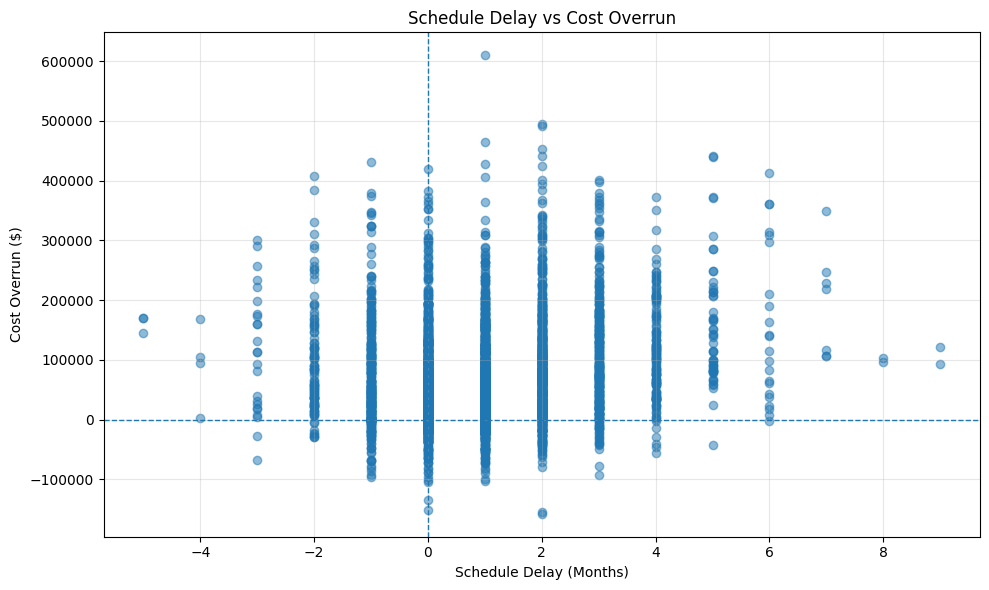

In [19]:
# Ensure numeric columns are numeric
numeric_cols = [
    "Schedule_Delay", "Cost_Overrun", "CPI_Cumulative",
    "SPI_Cumulative", "Forecast_Overrun_Percent"
]

for col in numeric_cols:
    portfolio_df[col] = pd.to_numeric(portfolio_df[col], errors="coerce")

# --------------------------------------------------
# GRAPH 1: Schedule Delay vs Cost Overrun
# --------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    portfolio_df["Schedule_Delay"],
    portfolio_df["Cost_Overrun"],
    alpha=0.5
)

plt.axhline(0, linestyle="--", linewidth=1)
plt.axvline(0, linestyle="--", linewidth=1)

plt.title("Schedule Delay vs Cost Overrun")
plt.xlabel("Schedule Delay (Months)")
plt.ylabel("Cost Overrun ($)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


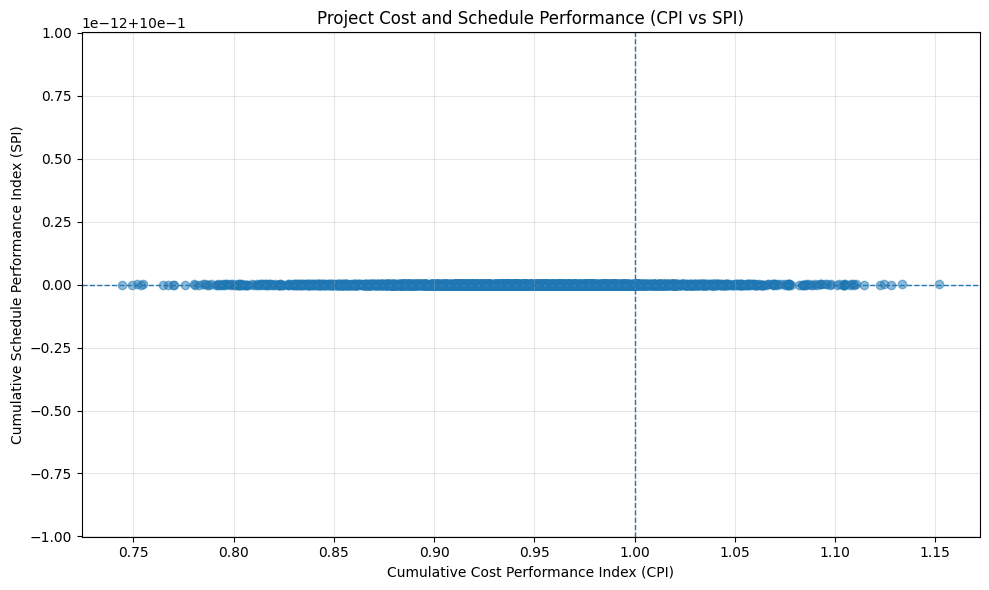

In [20]:
# --------------------------------------------------
# GRAPH 2: CPI vs SPI Performance
# --------------------------------------------------
plt.figure(figsize=(10, 6))

plt.scatter(
    portfolio_df["CPI_Cumulative"],
    portfolio_df["SPI_Cumulative"],
    alpha=0.5
)

plt.axvline(1, linestyle="--", linewidth=1)
plt.axhline(1, linestyle="--", linewidth=1)

plt.title("Project Cost and Schedule Performance (CPI vs SPI)")
plt.xlabel("Cumulative Cost Performance Index (CPI)")
plt.ylabel("Cumulative Schedule Performance Index (SPI)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

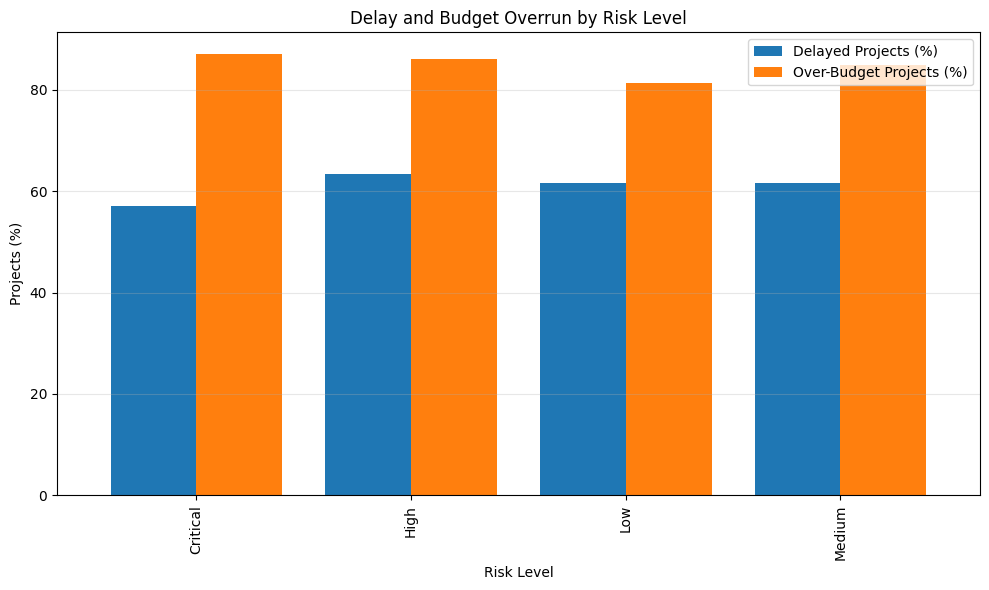

In [21]:
# --------------------------------------------------
# GRAPH 3: Delay and Budget Overrun by Risk Level
# --------------------------------------------------
risk_chart = (
    portfolio_df.groupby("Risk_Level")
    .agg(
        Delayed_Percent=("Delayed_Project", "mean"),
        Over_Budget_Percent=("Over_Budget_Project", "mean")
    ) * 100
).sort_index()

ax = risk_chart.plot(
    kind="bar",
    figsize=(10, 6),
    width=0.8
)

ax.set_title("Delay and Budget Overrun by Risk Level")
ax.set_xlabel("Risk Level")
ax.set_ylabel("Projects (%)")
ax.legend(["Delayed Projects (%)", "Over-Budget Projects (%)"])
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


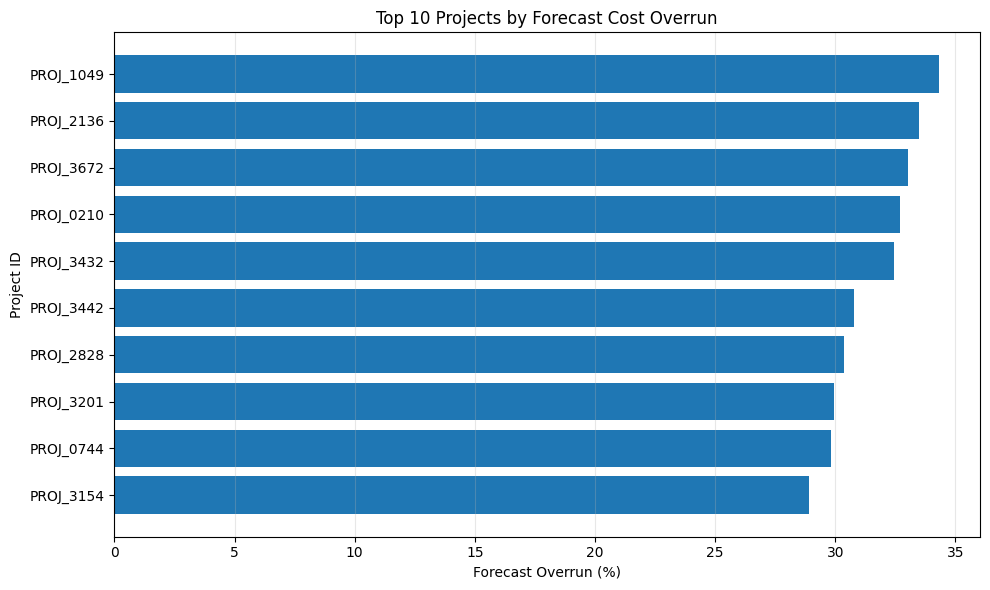

In [22]:
# --------------------------------------------------
# GRAPH 4: Top 10 Forecast Overruns
# --------------------------------------------------
top_overruns = (
    portfolio_df[portfolio_df["Forecast_Overrun_Percent"] > 0]
    .nlargest(10, "Forecast_Overrun_Percent")
    .sort_values("Forecast_Overrun_Percent")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_overruns["Project_ID"],
    top_overruns["Forecast_Overrun_Percent"]
)

plt.title("Top 10 Projects by Forecast Cost Overrun")
plt.xlabel("Forecast Overrun (%)")
plt.ylabel("Project ID")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


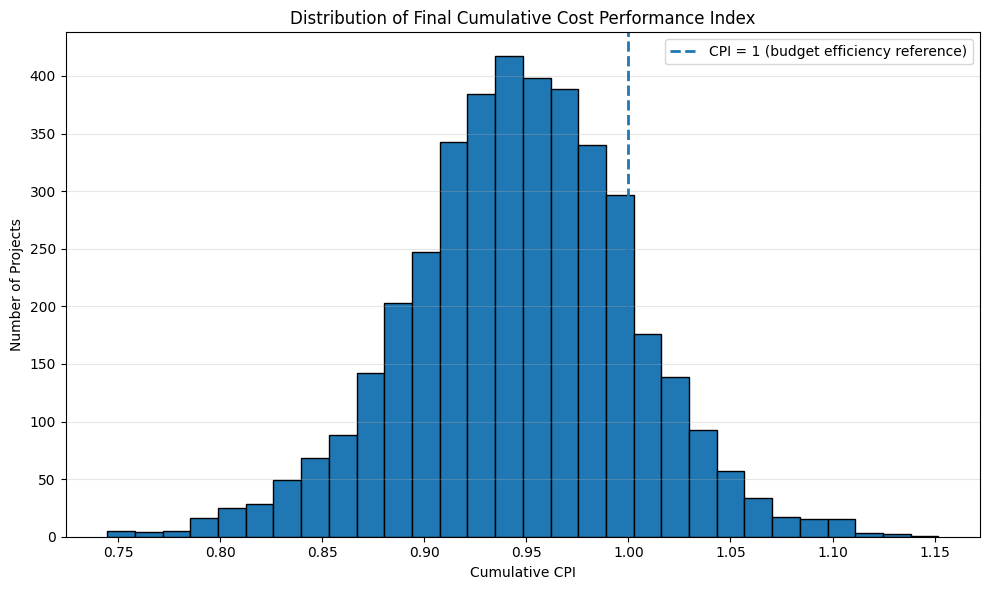

Median CPI: 0.948
Minimum CPI: 0.745
Maximum CPI: 1.152

Export completed.
File: ProjectCost_Delay_Intelligence.csv
Rows: 4000
Columns: 14
Unique projects: 4000


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:

import matplotlib.pyplot as plt
from google.colab import files

# --------------------------------------------------
# GRAPH: Distribution of Cumulative CPI
# --------------------------------------------------
plt.figure(figsize=(10, 6))

plt.hist(
    portfolio_df["CPI_Cumulative"].dropna(),
    bins=30,
    edgecolor="black"
)

plt.axvline(
    1.0,
    linestyle="--",
    linewidth=2,
    label="CPI = 1 (budget efficiency reference)"
)

plt.title("Distribution of Final Cumulative Cost Performance Index")
plt.xlabel("Cumulative CPI")
plt.ylabel("Number of Projects")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

print("Median CPI:", round(portfolio_df["CPI_Cumulative"].median(), 3))
print("Minimum CPI:", round(portfolio_df["CPI_Cumulative"].min(), 3))
print("Maximum CPI:", round(portfolio_df["CPI_Cumulative"].max(), 3))

# --------------------------------------------------
# EXPORT PORTFOLIO DATASET
# --------------------------------------------------
output_file = "ProjectCost_Delay_Intelligence.csv"

portfolio_df.to_csv(output_file, index=False)

print("\nExport completed.")
print("File:", output_file)
print("Rows:", len(portfolio_df))
print("Columns:", len(portfolio_df.columns))
print("Unique projects:", portfolio_df["Project_ID"].nunique())

files.download(output_file)